In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from rital_nlp_project.common.utils import load_clean_data
from rital_nlp_project.common.notebook_utils import init_notebook
from rital_nlp_project.common.models.word2vec import Word2VecPoolingTransformer
from rital_nlp_project.common.models.models_eval import eval_pipeline, eval_combination_matrix
from rital_nlp_project.movies.metrics import scoring

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC

import gensim.downloader as api

init_notebook()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
texts_movies, classes_movies = load_clean_data("../Dataset/movies_clean.parquet")

In [ ]:
model = api.load("word2vec-google-news-300")


In [ ]:
vectorizer_list = [
    Word2VecPoolingTransformer(model, pooling="mean"),
    Word2VecPoolingTransformer(model, pooling="max"),
    Word2VecPoolingTransformer(model, pooling="mean_max"),
    Word2VecPoolingTransformer(model, pooling="tfidf", vectorizer=TfidfVectorizer(min_df=5, max_df=0.5)),
    Word2VecPoolingTransformer(model, pooling="sif", vectorizer=CountVectorizer(min_df=5, max_df=0.5)),
]

classifier_list = [
    LogisticRegression(max_iter=100),
    LinearSVC(),
    SVC(kernel="rbf")
]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(texts_movies, classes_movies, random_state=42)

In [23]:
data = []
for vect in vectorizer_list:
    for clf in classifier_list:
        pipe = Pipeline([("vectorizer", vect), ("classifier", clf)])
        results = eval_pipeline(texts_movies, classes_movies, X_train, y_train, X_test, y_test, pipe, scoring, False, False)
        data.append(results)
results = pd.DataFrame(data=data)

Pipeline steps:
  vectorizer: Word2VecPoolingTransformer(pooling=mean)
  classifier: LogisticRegression()
Training time: 0.641 seconds
Inference time: 0.172 seconds
Test accuracy: 0.7780
Test precision: 0.7705
Test recall: 0.7737
Test f1: 0.7721

Pipeline steps:
  vectorizer: Word2VecPoolingTransformer(pooling=mean)
  classifier: LinearSVC()
Training time: 0.507 seconds
Inference time: 0.143 seconds
Test accuracy: 0.8080
Test precision: 0.8025
Test recall: 0.8025
Test f1: 0.8025

Pipeline steps:
  vectorizer: Word2VecPoolingTransformer(pooling=mean)
  classifier: SVC()
Training time: 0.579 seconds
Inference time: 0.209 seconds
Test accuracy: 0.8060
Test precision: 0.8042
Test recall: 0.7942
Test f1: 0.7992

Pipeline steps:
  vectorizer: Word2VecPoolingTransformer(pooling=max)
  classifier: LogisticRegression()
Training time: 0.454 seconds
Inference time: 0.144 seconds
Test accuracy: 0.6820
Test precision: 0.6680
Test recall: 0.6872
Test f1: 0.6775

Pipeline steps:
  vectorizer: Word2Ve

<Axes: xlabel='classifier', ylabel='vectorizer'>

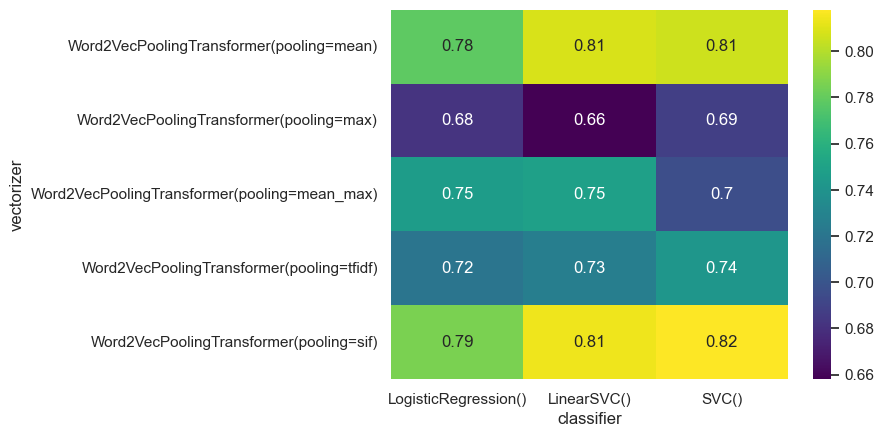

In [24]:
sns.heatmap(results.pivot(columns="classifier", index="vectorizer", values="accuracy"), annot=True, cmap="viridis")

<Axes: xlabel='classifier', ylabel='vectorizer'>

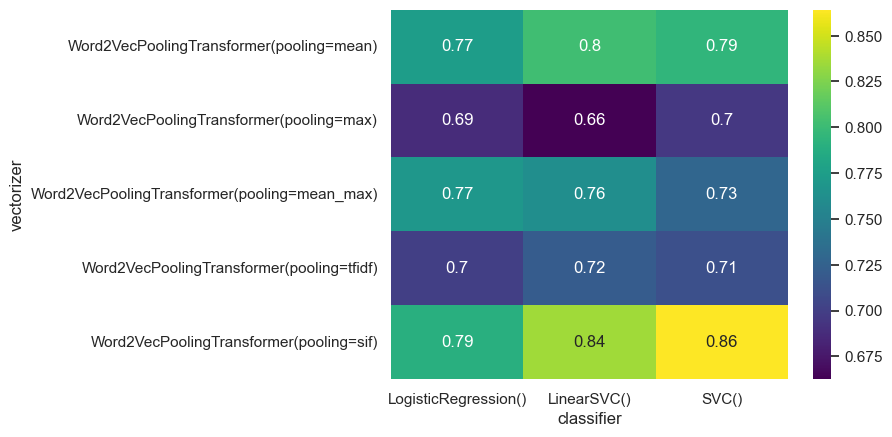

In [25]:
sns.heatmap(results.pivot(columns="classifier", index="vectorizer", values="recall"), annot=True, cmap="viridis")

<Axes: xlabel='classifier', ylabel='vectorizer'>

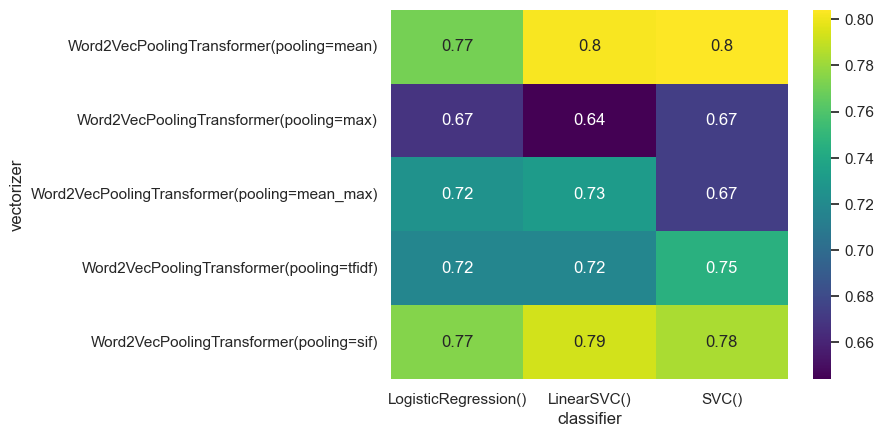

In [26]:
sns.heatmap(results.pivot(columns="classifier", index="vectorizer", values="precision"), annot=True, cmap="viridis")